# Task 2: DEIMOS Lya Templates

## Intrinsic vs Attenuated Spectra

**Intrinsic spectrum**: the Lya line as emitted by the galaxy — its true shape before any IGM absorption.  
**Attenuated spectrum**: what we actually observe after IGM absorption:
$$T_{\rm obs}(\lambda) = T_{\rm intrinsic}(\lambda) \times T_{\rm IGM}(\lambda)$$

At **z ≤ 5** the IGM is almost fully ionized → $T_{\rm IGM} \approx 1$ → **observed ≈ intrinsic**.  
At **z ~ 7.5** the IGM is ~50% neutral → heavy absorption on the blue side (GP trough) and a damping wing on the red side → **observed ≪ intrinsic** near 1216 Å.

**The DEIMOS spectra at z=3–6 give us the intrinsic line shapes** (the IGM is transparent at those redshifts).  
We will convolve those templates with the simulation transmission curves to generate mock z~7.5 observed spectra for Task 3.

In [1]:
from pathlib import Path
import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits

DATA_DIR = Path.cwd().parent / 'data' / 'deimos_deeper_than_deep'
LYA_REST = 1216.0  # Å

# Load catalog
cat = Table.read(DATA_DIR / 'DEIMOS_EGS_UrbanoStawinski.fits')
good = cat[(cat['Q_flag'] >= 3) & (cat['z_helio'] > 2) & (cat['z_helio'] < 6.5)]
print(f'Secure LAEs z=2–6.5: {len(good)}')

# Build ID → filepath lookup
all_fits = glob.glob(str(DATA_DIR / '1dspec' / '**' / '*.fits'), recursive=True)
id_to_path = {int(f.split('.')[-2]): f for f in all_fits}
print(f'FITS files indexed: {len(id_to_path)}')

Secure LAEs z=2–6.5: 168
FITS files indexed: 947


In [2]:
def load_spectrum(obj_id):
    """Load flux and wavelength for one object. Returns (wav_Å, flux) in observed frame."""
    path = id_to_path.get(obj_id)
    if path is None:
        return None, None
    with fits.open(path) as hdul:
        # Use Horne-B (blue arm, optimal extraction) — best S/N
        ext = hdul['Horne-B'].data
        wav  = ext['LAMBDA'][0].astype(np.float64)   # Å, observed frame
        flux = ext['SPEC'][0].astype(np.float64)
        ivar = ext['IVAR'][0].astype(np.float64)
    # Mask bad pixels (ivar=0)
    flux[ivar == 0] = np.nan
    return wav, flux


def lya_restframe(wav_obs, flux, z, width_aa=40):
    """Cut ±width_aa Å around Lya in rest frame."""
    wav_rest = wav_obs / (1 + z)
    mask = np.abs(wav_rest - LYA_REST) < width_aa
    return wav_rest[mask], flux[mask]

## Plot a few Lya lines across redshifts

/tmp/ipykernel_238745/1579382094.py:30: RuntimeWarning: All-NaN slice encountered
  peak = np.nanmax(fl)


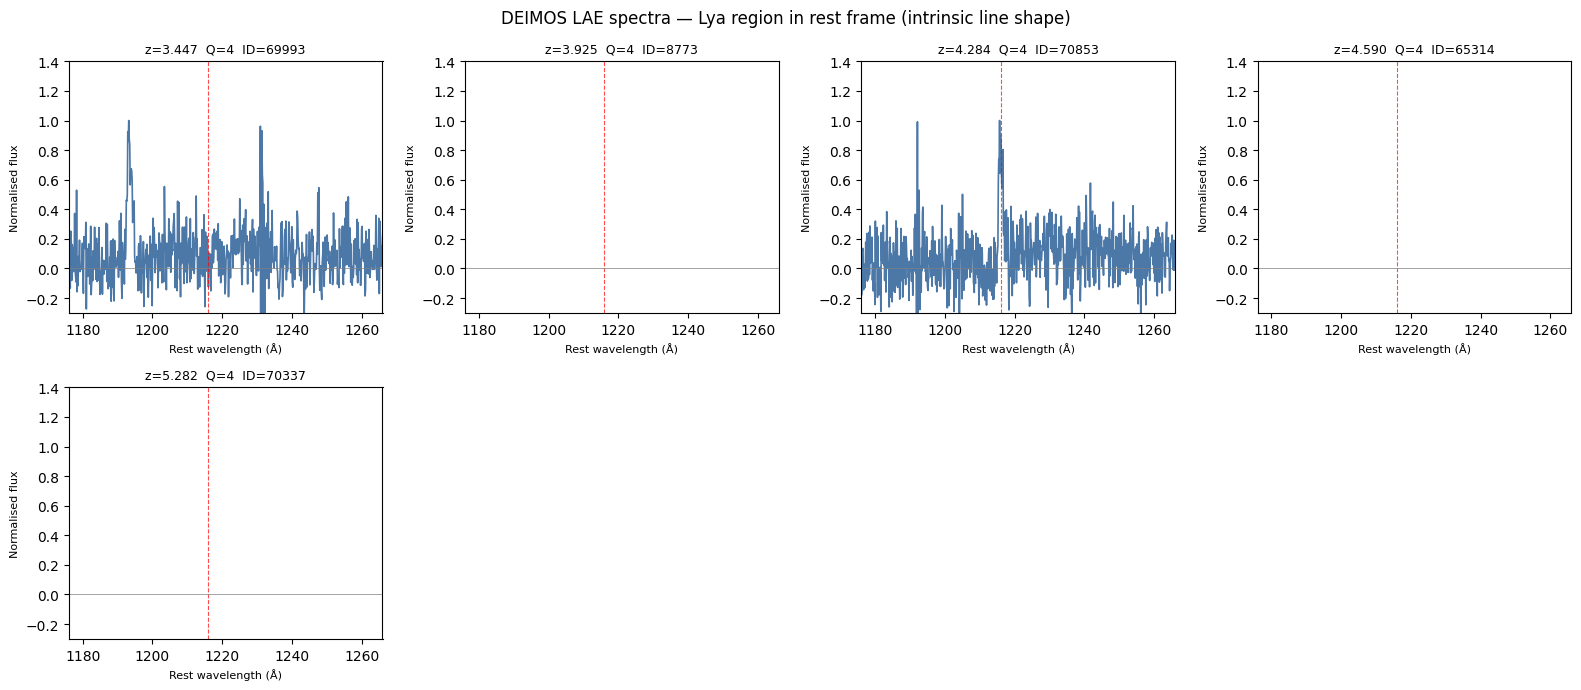

In [3]:
# Pick ~8 objects spread across z=3-6.5
z_bins   = [(3.0,3.5),(3.5,4.0),(4.0,4.5),(4.5,5.0),(5.0,5.5),(5.5,6.0),(6.0,6.5)]
selected = []
for zlo, zhi in z_bins:
    sub = good[(good['z_helio'] >= zlo) & (good['z_helio'] < zhi)]
    # prefer Q=4
    sub.sort('Q_flag', reverse=True)
    for row in sub:
        if row['ID'] in id_to_path:
            selected.append(row)
            break

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, row in zip(axes, selected):
    wav_obs, flux = load_spectrum(row['ID'])
    if wav_obs is None:
        ax.set_visible(False)
        continue

    z = row['z_helio']
    wav_r, fl = lya_restframe(wav_obs, flux, z, width_aa=50)

    if len(wav_r) < 10:
        ax.set_visible(False)
        continue

    # Normalise by peak flux (ignore NaNs)
    peak = np.nanmax(fl)
    if peak <= 0:
        ax.set_visible(False)
        continue
    fl_norm = fl / peak

    ax.plot(wav_r, fl_norm, color='#4C78A8', linewidth=1.2)
    ax.axvline(LYA_REST, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_xlim(LYA_REST - 40, LYA_REST + 50)
    ax.set_ylim(-0.3, 1.4)
    ax.set_title(f'z={z:.3f}  Q={row["Q_flag"]}  ID={row["ID"]}', fontsize=9)
    ax.set_xlabel('Rest wavelength (Å)', fontsize=8)
    ax.set_ylabel('Normalised flux', fontsize=8)
    ax.axhline(0, color='gray', linewidth=0.5)

# Hide unused panels
for ax in axes[len(selected):]:
    ax.set_visible(False)

fig.suptitle('DEIMOS LAE spectra — Lya region in rest frame (intrinsic line shape)', fontsize=12)
fig.tight_layout()
plt.show()

## Compare: intrinsic (DEIMOS z~4) vs attenuated (simulation z~7.5)

/tmp/ipykernel_238745/2364678068.py:19: RuntimeWarning: All-NaN slice encountered
  peak = np.nanmax(fl)


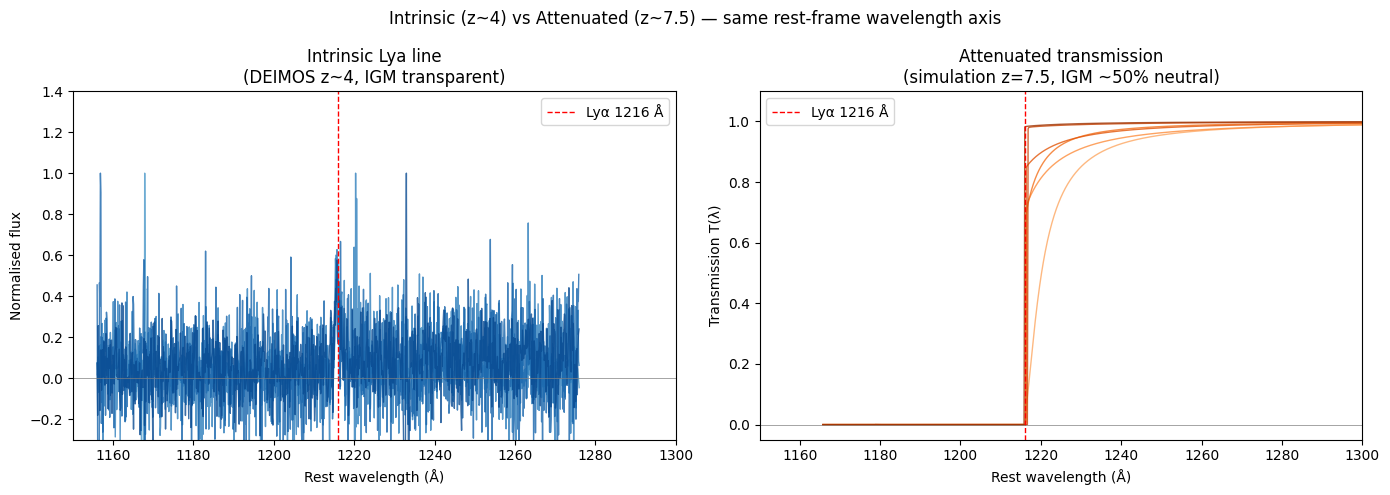

Note: mock z~7.5 lines = intrinsic × transmission (Task 3)


In [4]:
# Load a few simulation transmission curves for comparison
sim_data = np.load(Path.cwd().parent / 'results' / 'task1_transmission_to_bubble_size' / 'dataset_z7.4985.npz')
sim_wav  = sim_data['wav']          # rest-frame Å, ascending
sim_T    = sim_data['transmission'] # (10000, 2000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: a few intrinsic DEIMOS spectra at z~4 (IGM transparent → intrinsic)
ax = axes[0]
z4_objs = good[(good['z_helio'] >= 3.5) & (good['z_helio'] < 4.5) & (good['Q_flag'] == 4)]
colors = plt.cm.Blues(np.linspace(0.4, 0.9, min(6, len(z4_objs))))
plotted = 0
for row, col in zip(z4_objs, colors):
    if plotted >= 6: break
    wav_obs, flux = load_spectrum(row['ID'])
    if wav_obs is None: continue
    wav_r, fl = lya_restframe(wav_obs, flux, row['z_helio'], width_aa=60)
    if len(wav_r) < 10: continue
    peak = np.nanmax(fl)
    if peak <= 0: continue
    ax.plot(wav_r, fl/peak, color=col, linewidth=1.0, alpha=0.8)
    plotted += 1
ax.axvline(LYA_REST, color='red', linestyle='--', linewidth=1, label='Lyα 1216 Å')
ax.set_xlim(1150, 1300)
ax.set_ylim(-0.3, 1.4)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Rest wavelength (Å)')
ax.set_ylabel('Normalised flux')
ax.set_title('Intrinsic Lya line\n(DEIMOS z~4, IGM transparent)')
ax.legend()

# Right: a few simulation transmission curves at z=7.5 (attenuated)
ax = axes[1]
colors2 = plt.cm.Oranges(np.linspace(0.4, 0.9, 6))
# pick sightlines with varying transmission level
med_T = sim_T[:, (sim_wav > 1210) & (sim_wav < 1225)].mean(axis=1)
idx_sorted = np.argsort(med_T)
picks = idx_sorted[np.linspace(0, len(idx_sorted)-1, 6, dtype=int)]
for i, col in zip(picks, colors2):
    ax.plot(sim_wav, sim_T[i], color=col, linewidth=1.0, alpha=0.8)
ax.axvline(LYA_REST, color='red', linestyle='--', linewidth=1, label='Lyα 1216 Å')
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlim(1150, 1300)
ax.set_ylim(-0.05, 1.1)
ax.set_xlabel('Rest wavelength (Å)')
ax.set_ylabel('Transmission T(λ)')
ax.set_title('Attenuated transmission\n(simulation z=7.5, IGM ~50% neutral)')
ax.legend()

fig.suptitle('Intrinsic (z~4) vs Attenuated (z~7.5) — same rest-frame wavelength axis', fontsize=12)
fig.tight_layout()
plt.show()
print('Note: mock z~7.5 lines = intrinsic × transmission (Task 3)')

## Redshift distribution of the template sample

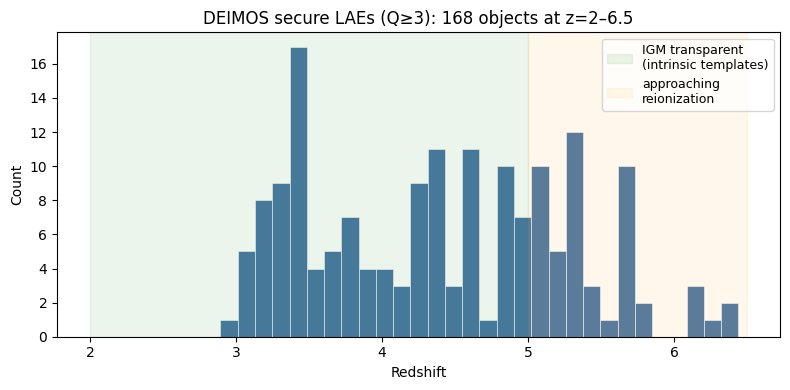

z=2-5: 116 objects  ←  best for intrinsic templates
z=5-6.5: 52 objects  ←  some IGM attenuation already present


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
z_all = good['z_helio']
ax.hist(z_all, bins=30, color='#4C78A8', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Redshift')
ax.set_ylabel('Count')
ax.set_title(f'DEIMOS secure LAEs (Q≥3): {len(good)} objects at z=2–6.5')
for zlo, zhi, label in [(2,5,'IGM transparent\n(intrinsic templates)'), (5,6.5,'approaching\nreionization')]:
    ax.axvspan(zlo, zhi, alpha=0.08, color='green' if zhi<=5 else 'orange', label=label)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()
print(f'z=2-5: {((z_all>=2)&(z_all<5)).sum()} objects  ←  best for intrinsic templates')
print(f'z=5-6.5: {((z_all>=5)&(z_all<6.5)).sum()} objects  ←  some IGM attenuation already present')